In [6]:
#  1. IMPORTS 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("EDA Started...")

EDA Started...


In [ ]:
#  2. LOAD DATA 
train = pd.read_csv("data/cardekho_dataset.csv")
print("Shape:", train.shape)
train.head()

Shape: (15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
#  3. DATA OVERVIEW 
train.info()

print("\nData Types:")
print(train.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB

Data Types:
Unnamed: 0             int64
car_name           

In [ ]:
#  4. CLEANING 
if 'Unnamed: 0' in train.columns:
    train.drop('Unnamed: 0', axis=1, inplace=True)
    print("Removed Unnamed column")

train.head()

Removed Unnamed column


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [10]:
# Separate columns
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train.select_dtypes(include=['object']).columns

# Fill numerical missing values with median
for col in numeric_cols:
    train[col].fillna(train[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in categorical_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)

# Check
print(train.isnull().sum())

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


## Key Insights
1. Selling price decreases as vehicle age increases.
2. Premium brands tend to have higher selling prices.
3. Higher kilometers driven usually reduce the selling price.
4. Log transformation reduced skewness in selling price.
5. Outliers were removed to improve model performance.

In [11]:
# Remove outliers using IQR for selling_price
Q1 = train['selling_price'].quantile(0.25)
Q3 = train['selling_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

train = train[(train['selling_price'] >= lower) & (train['selling_price'] <= upper)]

print("New Shape:", train.shape)

New Shape: (14025, 13)


In [ ]:
#  5. DATA QUALITY 
print("Missing Values:\n", train.isnull().sum())

print("\nDuplicates:", train.duplicated().sum())

Missing Values:
 car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Duplicates: 152


In [ ]:
#  6. SUMMARY 
# select all columns with numeric data types (int, float) and store their names
numeric_cols = train.select_dtypes(include=[np.number]).columns
# select all columns with object type (usually categorical/text) and store their names
categorical_cols = train.select_dtypes(include=['object']).columns

train[numeric_cols].describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,14025.000000,1.402500e+04,14025.000000,14025.00000,14025.000000,14025.000000,1.402500e+04
mean,6.153369,5.640948e+04,20.132019,1397.03451,91.493937,5.290838,5.738156e+05
std,3.051576,5.294995e+04,4.000928,422.91873,28.721932,0.765069,2.783796e+05
min,0.000000,1.000000e+02,7.810000,793.00000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.400000,1197.00000,74.000000,5.000000,3.680000e+05
50%,6.000000,5.000000e+04,20.000000,1248.00000,84.000000,5.000000,5.250000e+05
75%,8.000000,7.123300e+04,22.800000,1498.00000,103.260000,5.000000,7.250000e+05
max,29.000000,3.800000e+06,33.540000,5461.00000,364.900000,9.000000,1.485000e+06


In [ ]:
#  7. CATEGORICAL 
for col in categorical_cols:
    print(f"{col}: {train[col].nunique()} unique values")
    # print the number of unique categories in each categorical column
    print(train[col].value_counts().head(3))
    # print the top 3 most frequent values in the column
    print("-"*30)

car_name: 92 unique values
car_name
Hyundai i20           906
Maruti Swift Dzire    890
Maruti Swift          781
Name: count, dtype: int64
------------------------------
brand: 23 unique values
brand
Maruti     4992
Hyundai    2956
Honda      1463
Name: count, dtype: int64
------------------------------
model: 92 unique values
model
i20            906
Swift Dzire    890
Swift          781
Name: count, dtype: int64
------------------------------
seller_type: 3 unique values
seller_type
Dealer              8388
Individual          5465
Trustmark Dealer     172
Name: count, dtype: int64
------------------------------
fuel_type: 4 unique values
fuel_type
Petrol    7419
Diesel    6261
CNG        301
Name: count, dtype: int64
------------------------------
transmission_type: 2 unique values
transmission_type
Manual       11954
Automatic     2071
Name: count, dtype: int64
------------------------------


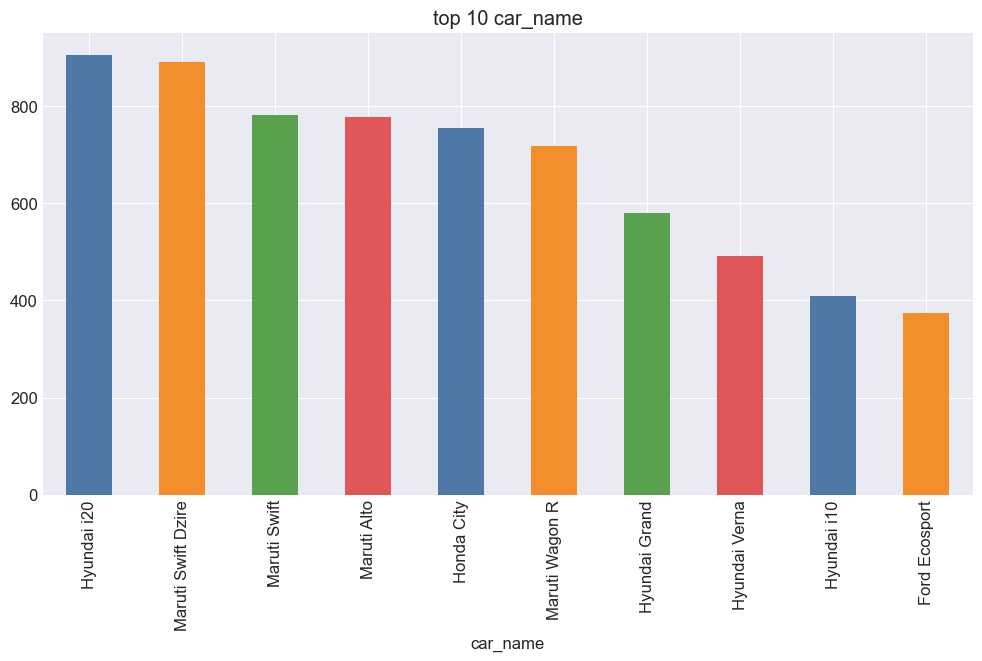

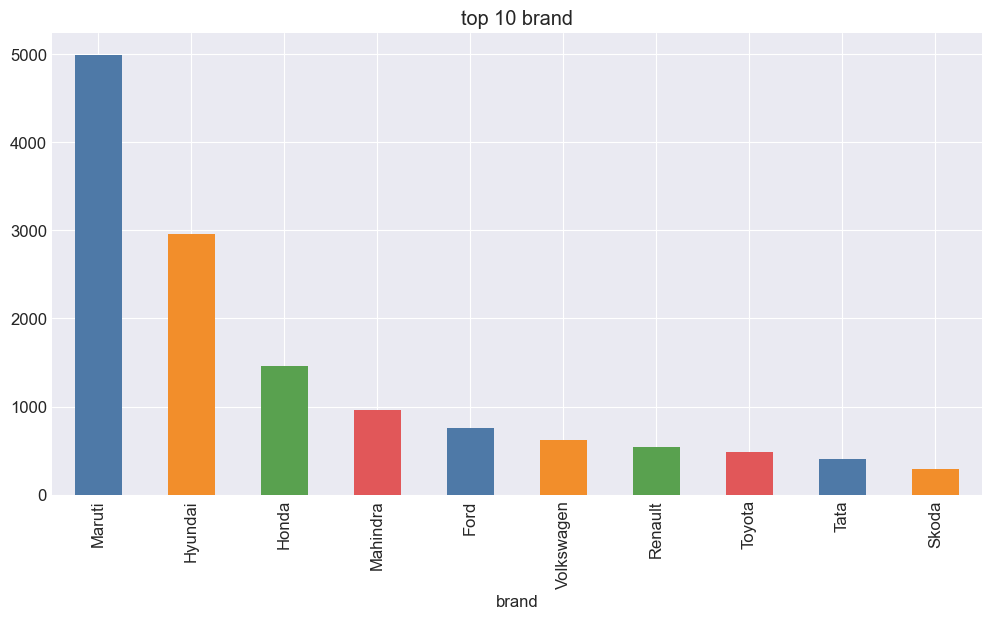

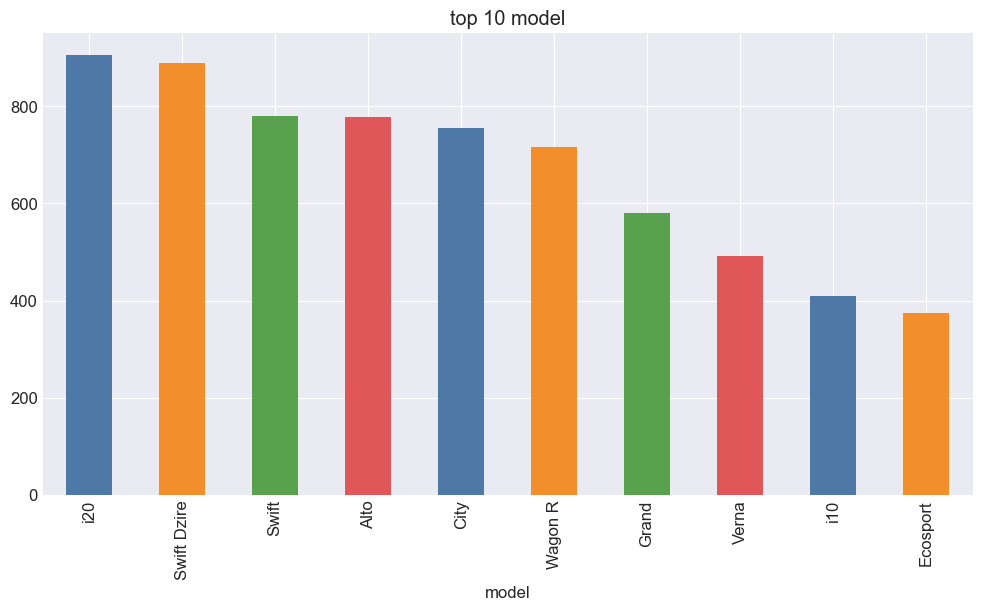

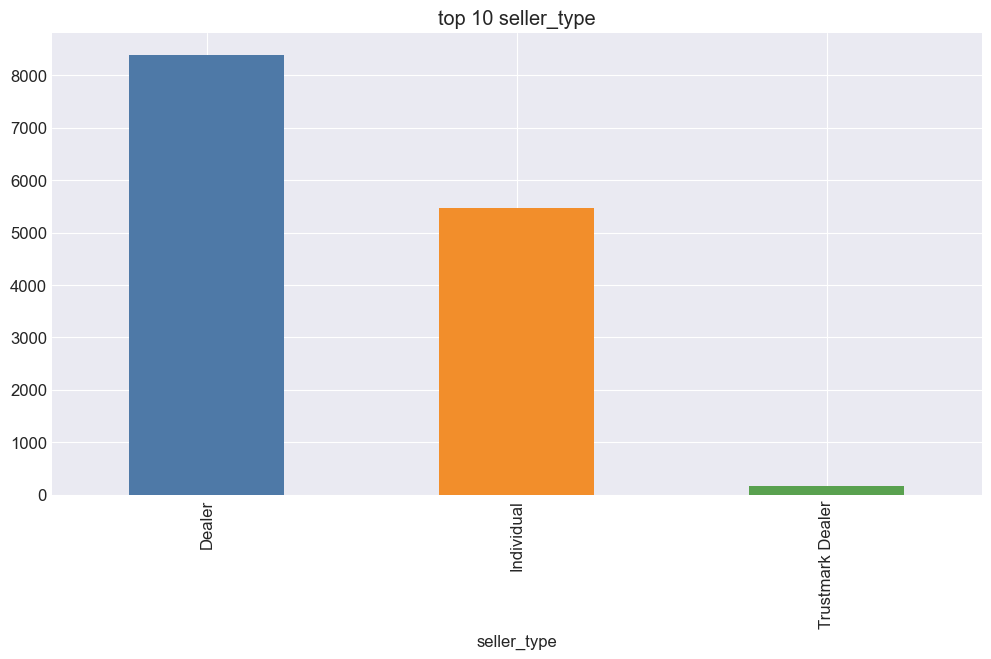

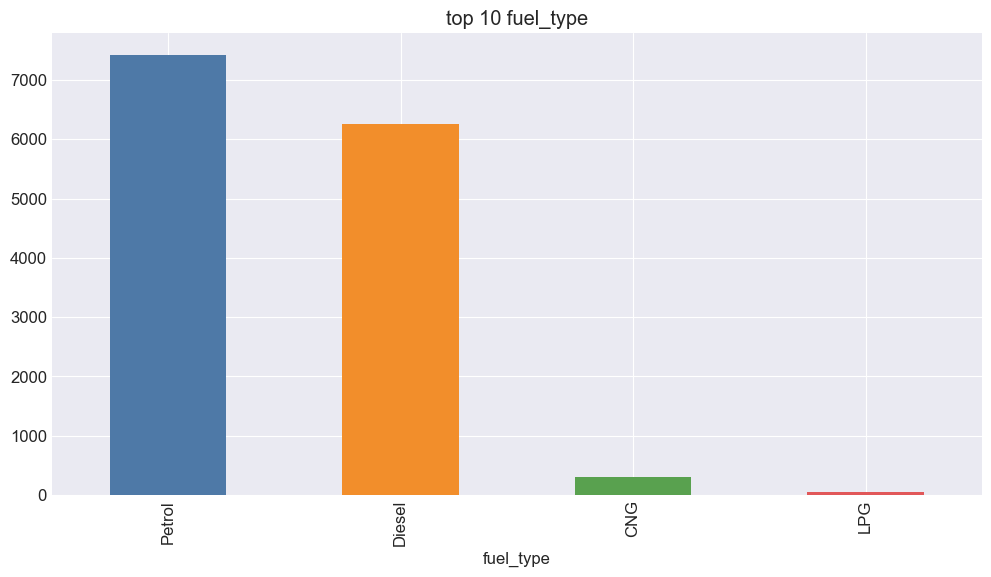

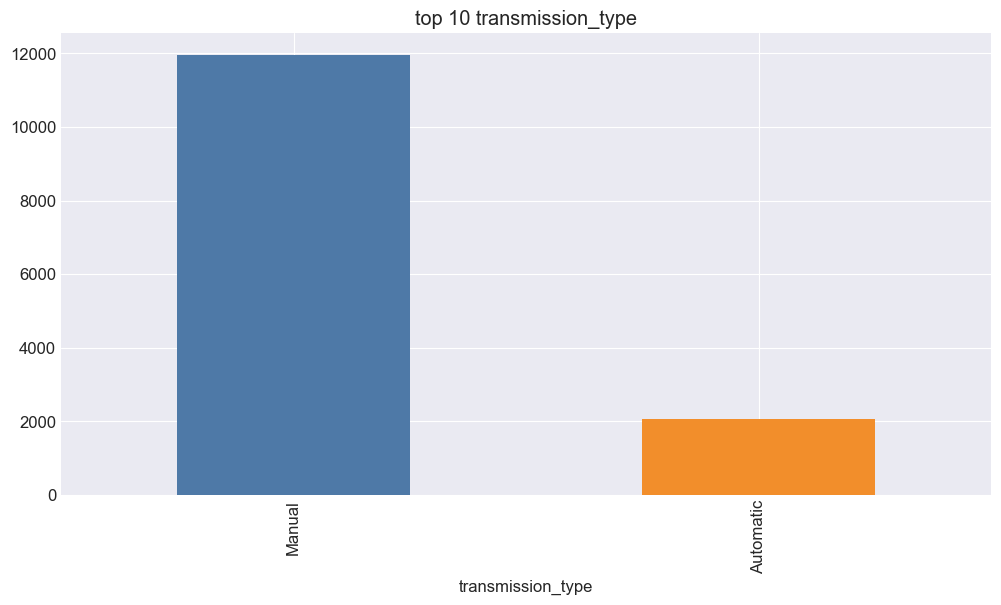

In [15]:
for col in categorical_cols:
    plt.Figure(figsize=(15,5))
    top10cars=train[col].value_counts()[:10]
    colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']
    top10cars.plot(kind='bar', color=colors)
    plt.title("top 10 " + col)
    plt.show()

In [16]:
top10cars=train['brand'].value_counts().head(10)
top10cars

brand
Maruti        4992
Hyundai       2956
Honda         1463
Mahindra       966
Ford           755
Volkswagen     620
Renault        536
Toyota         480
Tata           404
Skoda          297
Name: count, dtype: int64

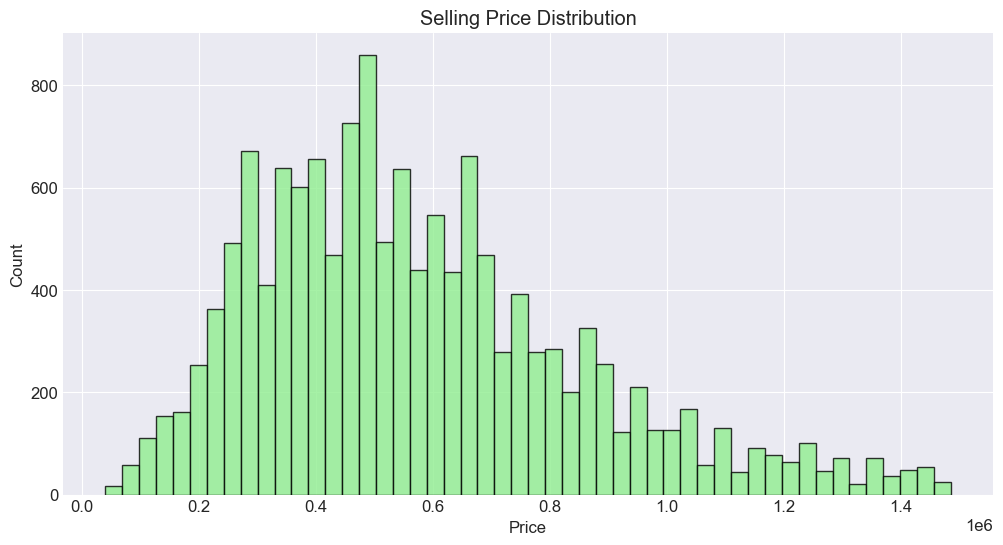

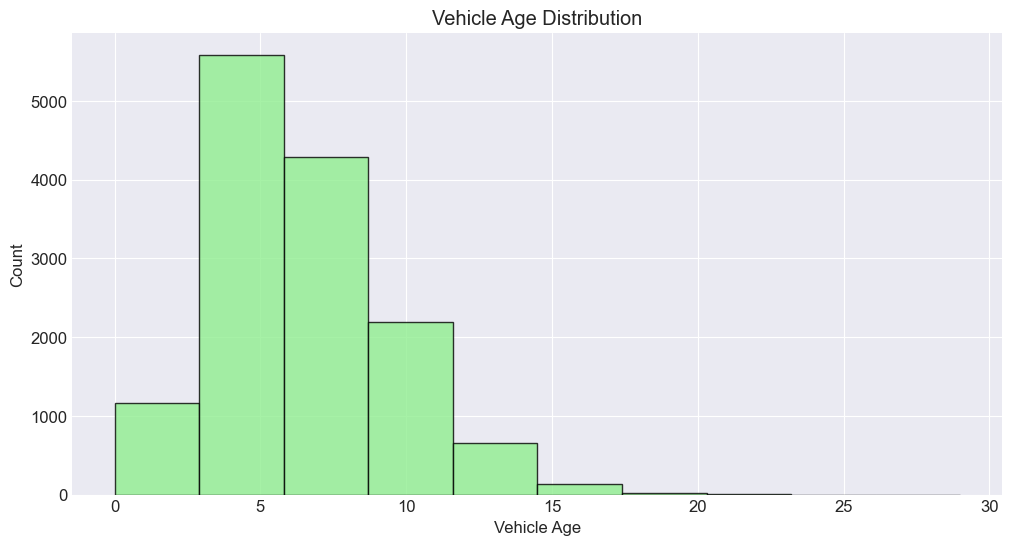

In [ ]:
#  8. UNIVARIATE 
train['selling_price'].plot(kind='hist',
           figsize=(12,6),
           alpha=.80,
           bins=50,
           color='lightgreen',
           grid=True, 
           edgecolor='black')
plt.title("Selling Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

train['vehicle_age'].plot(kind='hist',
           figsize=(12,6),
           alpha=.80,
           color='lightgreen',
           grid=True, 
           edgecolor='black')
plt.title("Vehicle Age Distribution")
plt.xlabel("Vehicle Age")
plt.ylabel("Count")
plt.show()

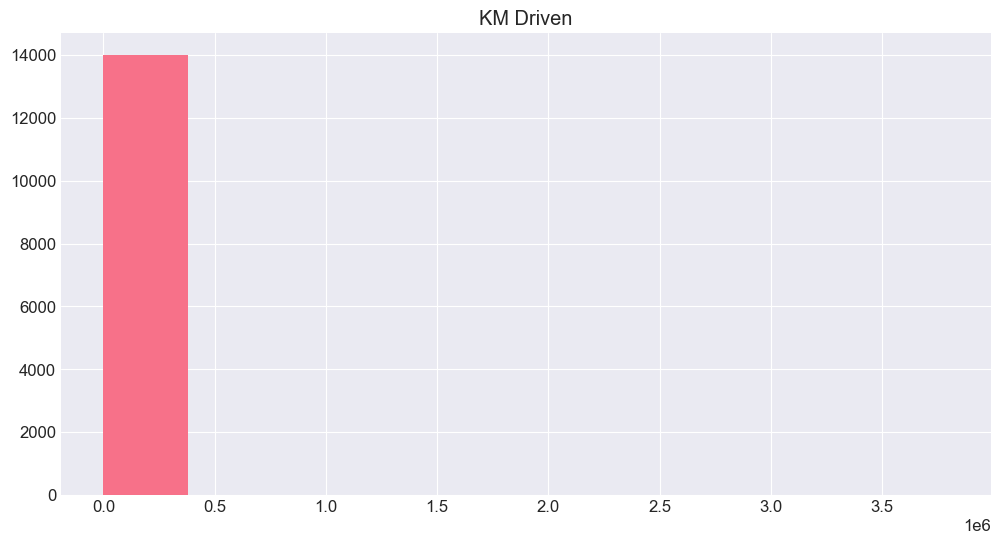

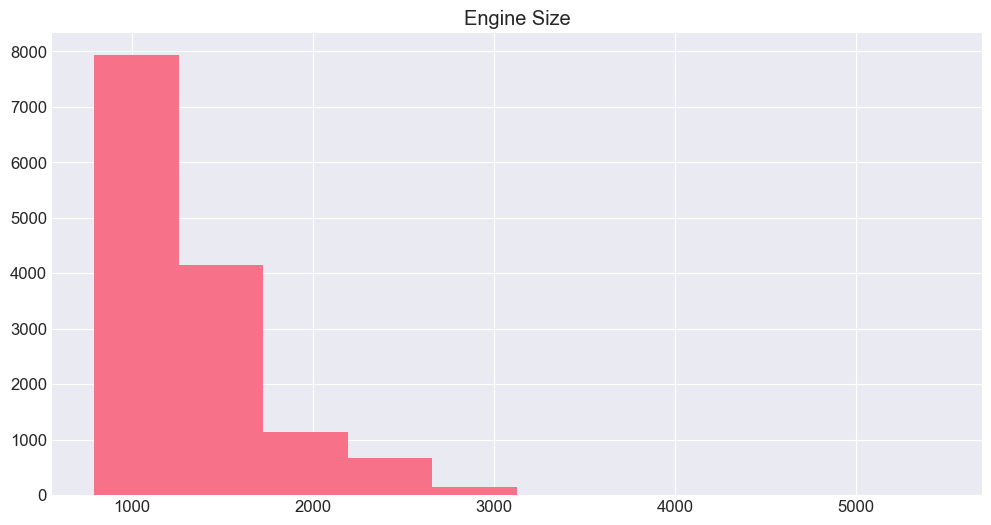

In [18]:
train['km_driven'].hist()
plt.title("KM Driven")
plt.show()

train['engine'].hist()
plt.title("Engine Size")
plt.show()

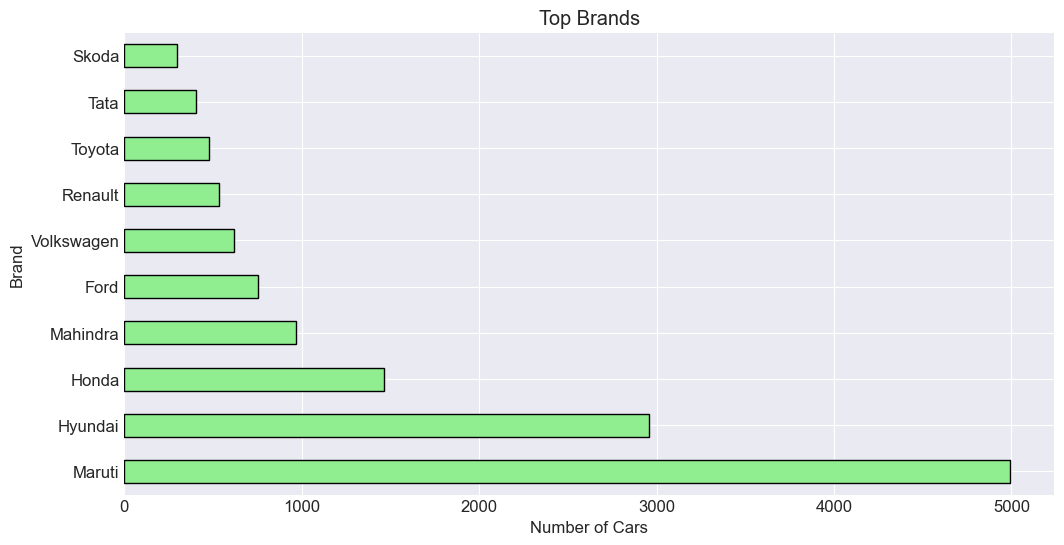

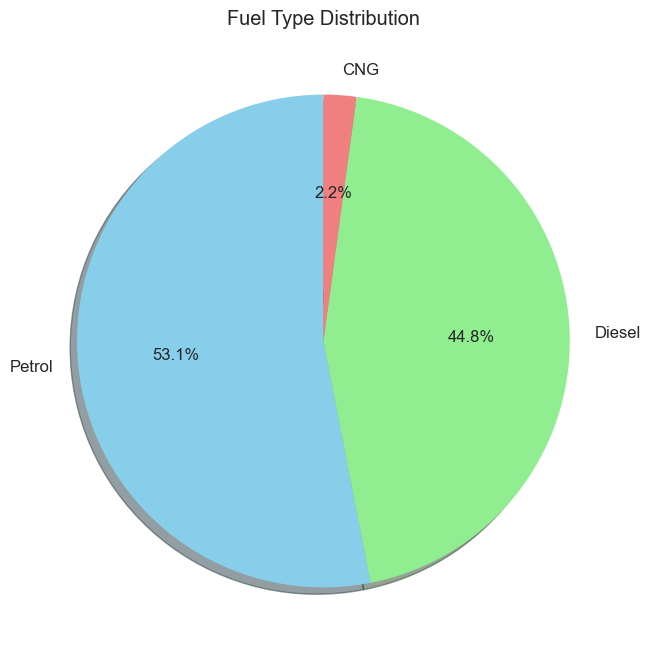

In [19]:
# Brand
train['brand'].value_counts().head(10).plot(
    kind='barh', 
    color='lightgreen',   
    edgecolor='black'     
)
plt.title("Top Brands")
plt.xlabel("Number of Cars")  
plt.ylabel("Brand") 
plt.show()

# Fuel
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold', 'pink']
train['fuel_type'].value_counts().head(3).plot(
    kind='pie',
    figsize=(8,8), 
    autopct='%1.1f%%', 
    colors=colors,
    startangle=90,
    shadow=True,

)
plt.title("Fuel Type Distribution")
plt.ylabel("")
plt.show()

In [20]:
train['fuel_type'].value_counts()

fuel_type
Petrol    7419
Diesel    6261
CNG        301
LPG         44
Name: count, dtype: int64

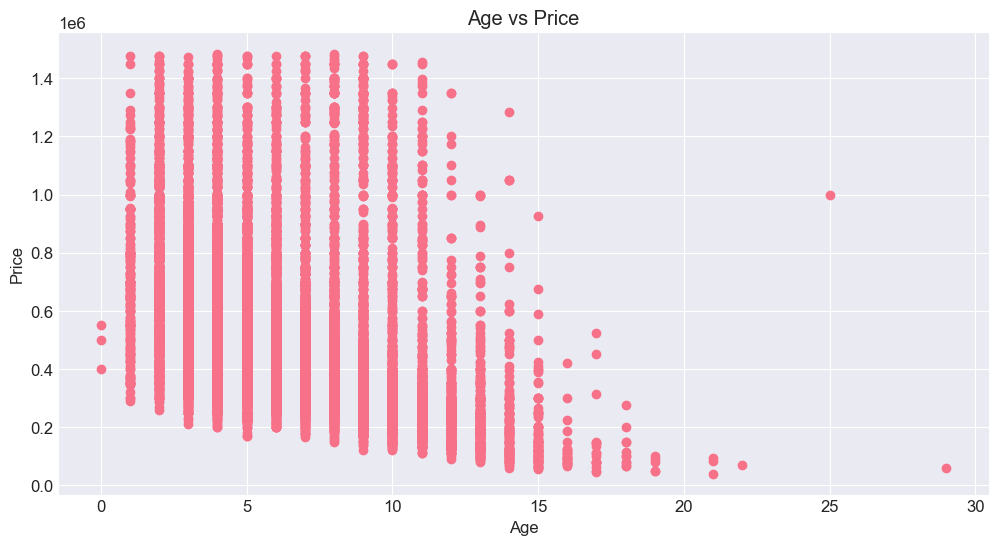

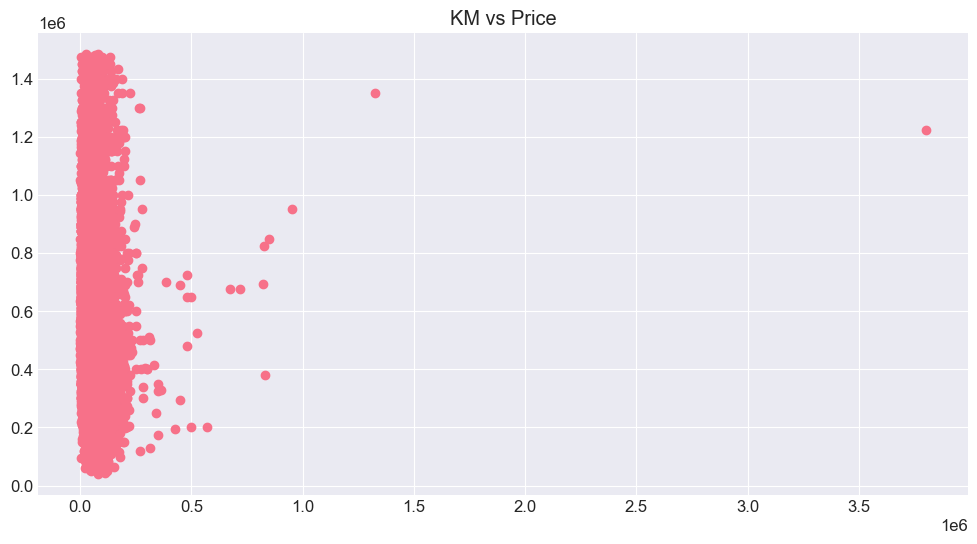

In [21]:
# Age vs Price
plt.scatter(train['vehicle_age'], train['selling_price'])
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Age vs Price")
plt.show()

# KM vs Price
plt.scatter(train['km_driven'], train['selling_price'])
plt.title("KM vs Price")
plt.show()

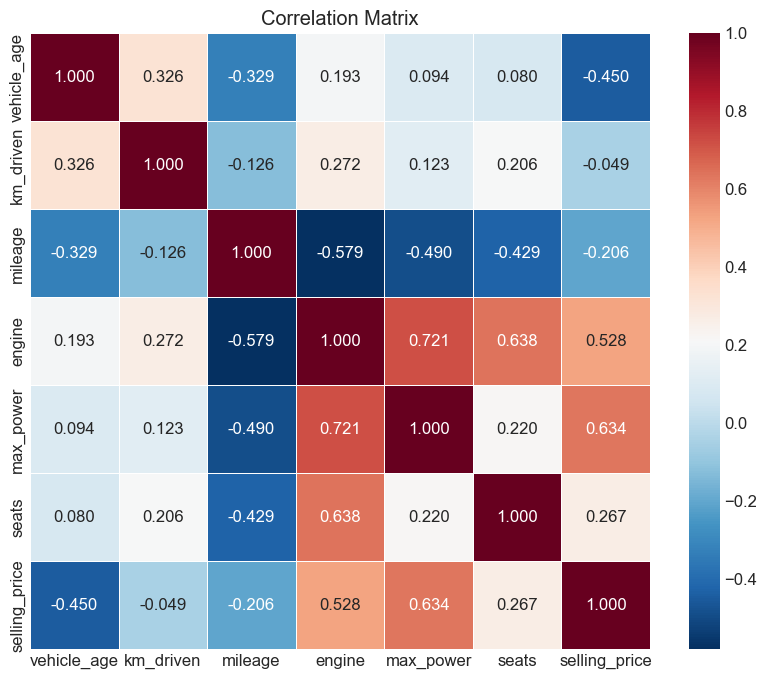

selling_price    1.000000
max_power        0.634179
engine           0.527551
seats            0.267457
km_driven       -0.048635
mileage         -0.205608
vehicle_age     -0.449703
Name: selling_price, dtype: float64

In [ ]:
#  12. CORRELATION 
corr = train[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='RdBu_r',lw='.5',fmt='.3f')
plt.title("Correlation Matrix")
plt.show()

corr['selling_price'].sort_values(ascending=False)

In [ ]:
#  13. OUTLIERS 
Q1 = train['selling_price'].quantile(0.25)
Q3 = train['selling_price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = train[(train['selling_price'] < lower) | (train['selling_price'] > upper)]

print("Outliers:", len(outliers))

Outliers: 371


In [ ]:
#  14. INSIGHTS 
print("Average Price:", train['selling_price'].mean())
print("Most Common Brand:", train['brand'].mode()[0])
print("Most Common Fuel:", train['fuel_type'].mode()[0])
print("Avg Age:", train['vehicle_age'].mean())

Average Price: 573815.6060606061
Most Common Brand: Maruti
Most Common Fuel: Petrol
Avg Age: 6.153368983957219


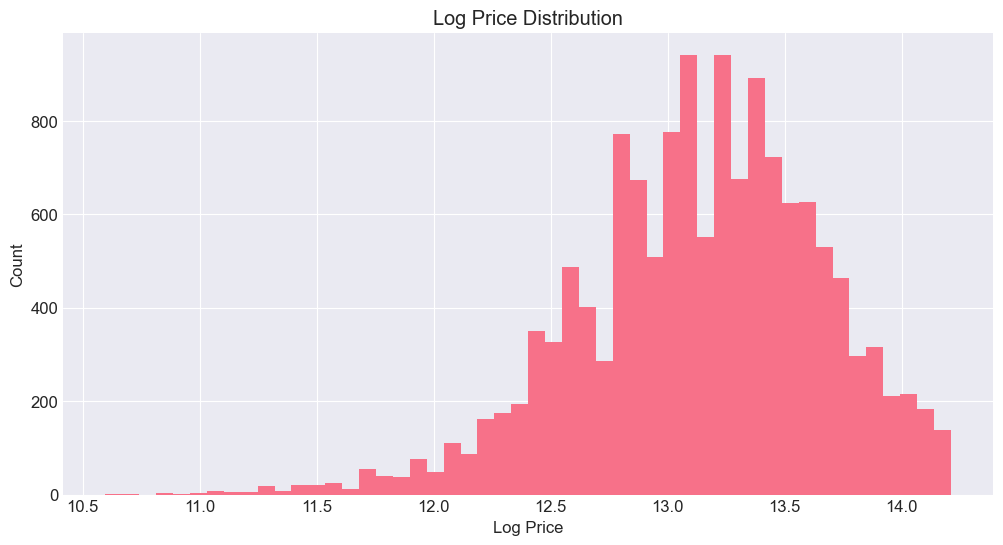

In [ ]:
# Log transformation 
import numpy as np

train['log_price'] = np.log1p(train['selling_price'])

plt.hist(train['log_price'], bins=50)
plt.title("Log Price Distribution")
plt.xlabel("Log Price")  
plt.ylabel("Count")
plt.show()

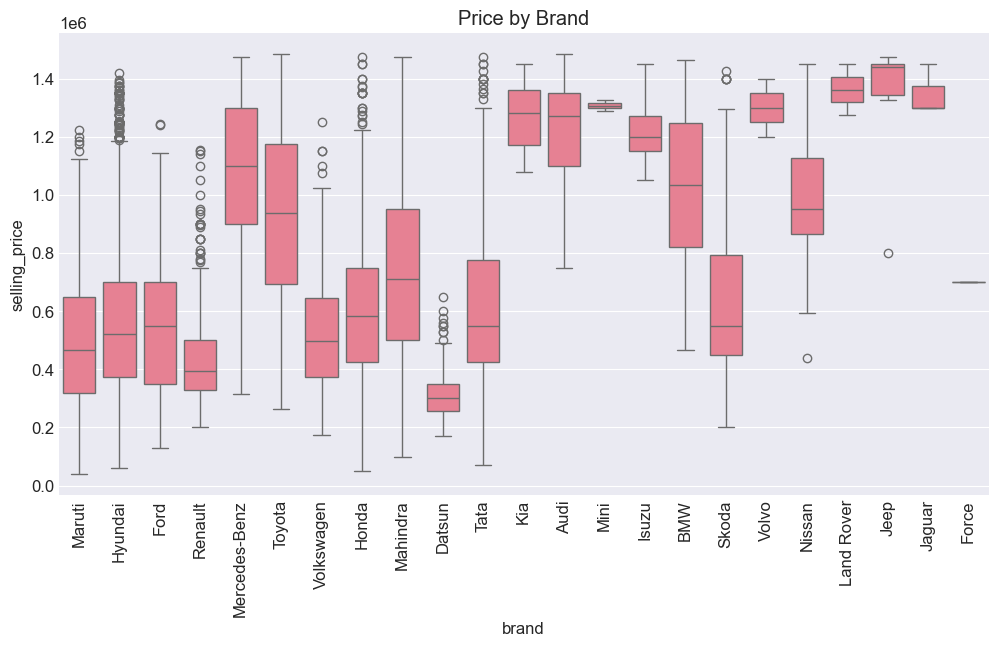

In [26]:
# Price vs Brand
plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='selling_price', data=train)
plt.xticks(rotation=90)
plt.title("Price by Brand")
plt.show()

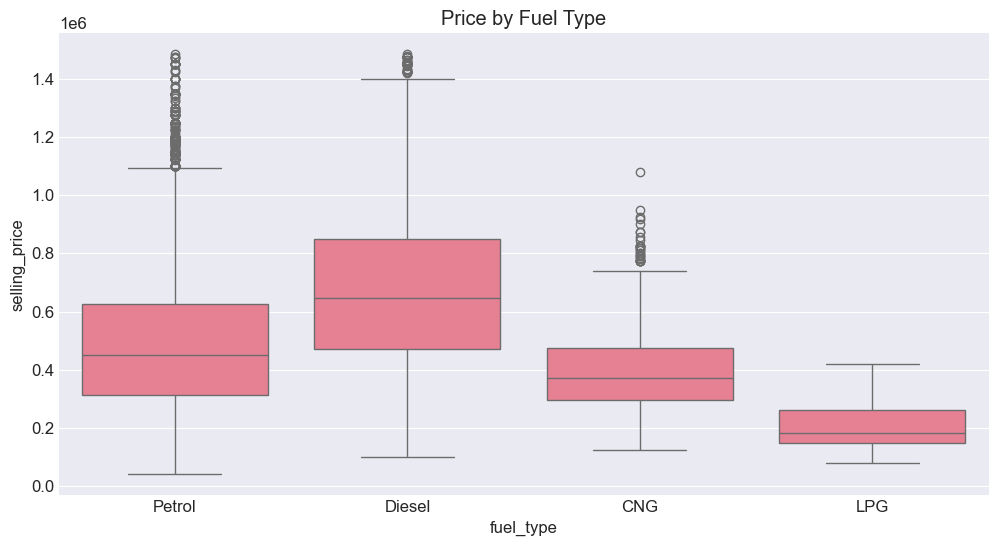

In [27]:
# Price vs Fuel
sns.boxplot(x='fuel_type', y='selling_price', data=train)
plt.title("Price by Fuel Type")
plt.show()

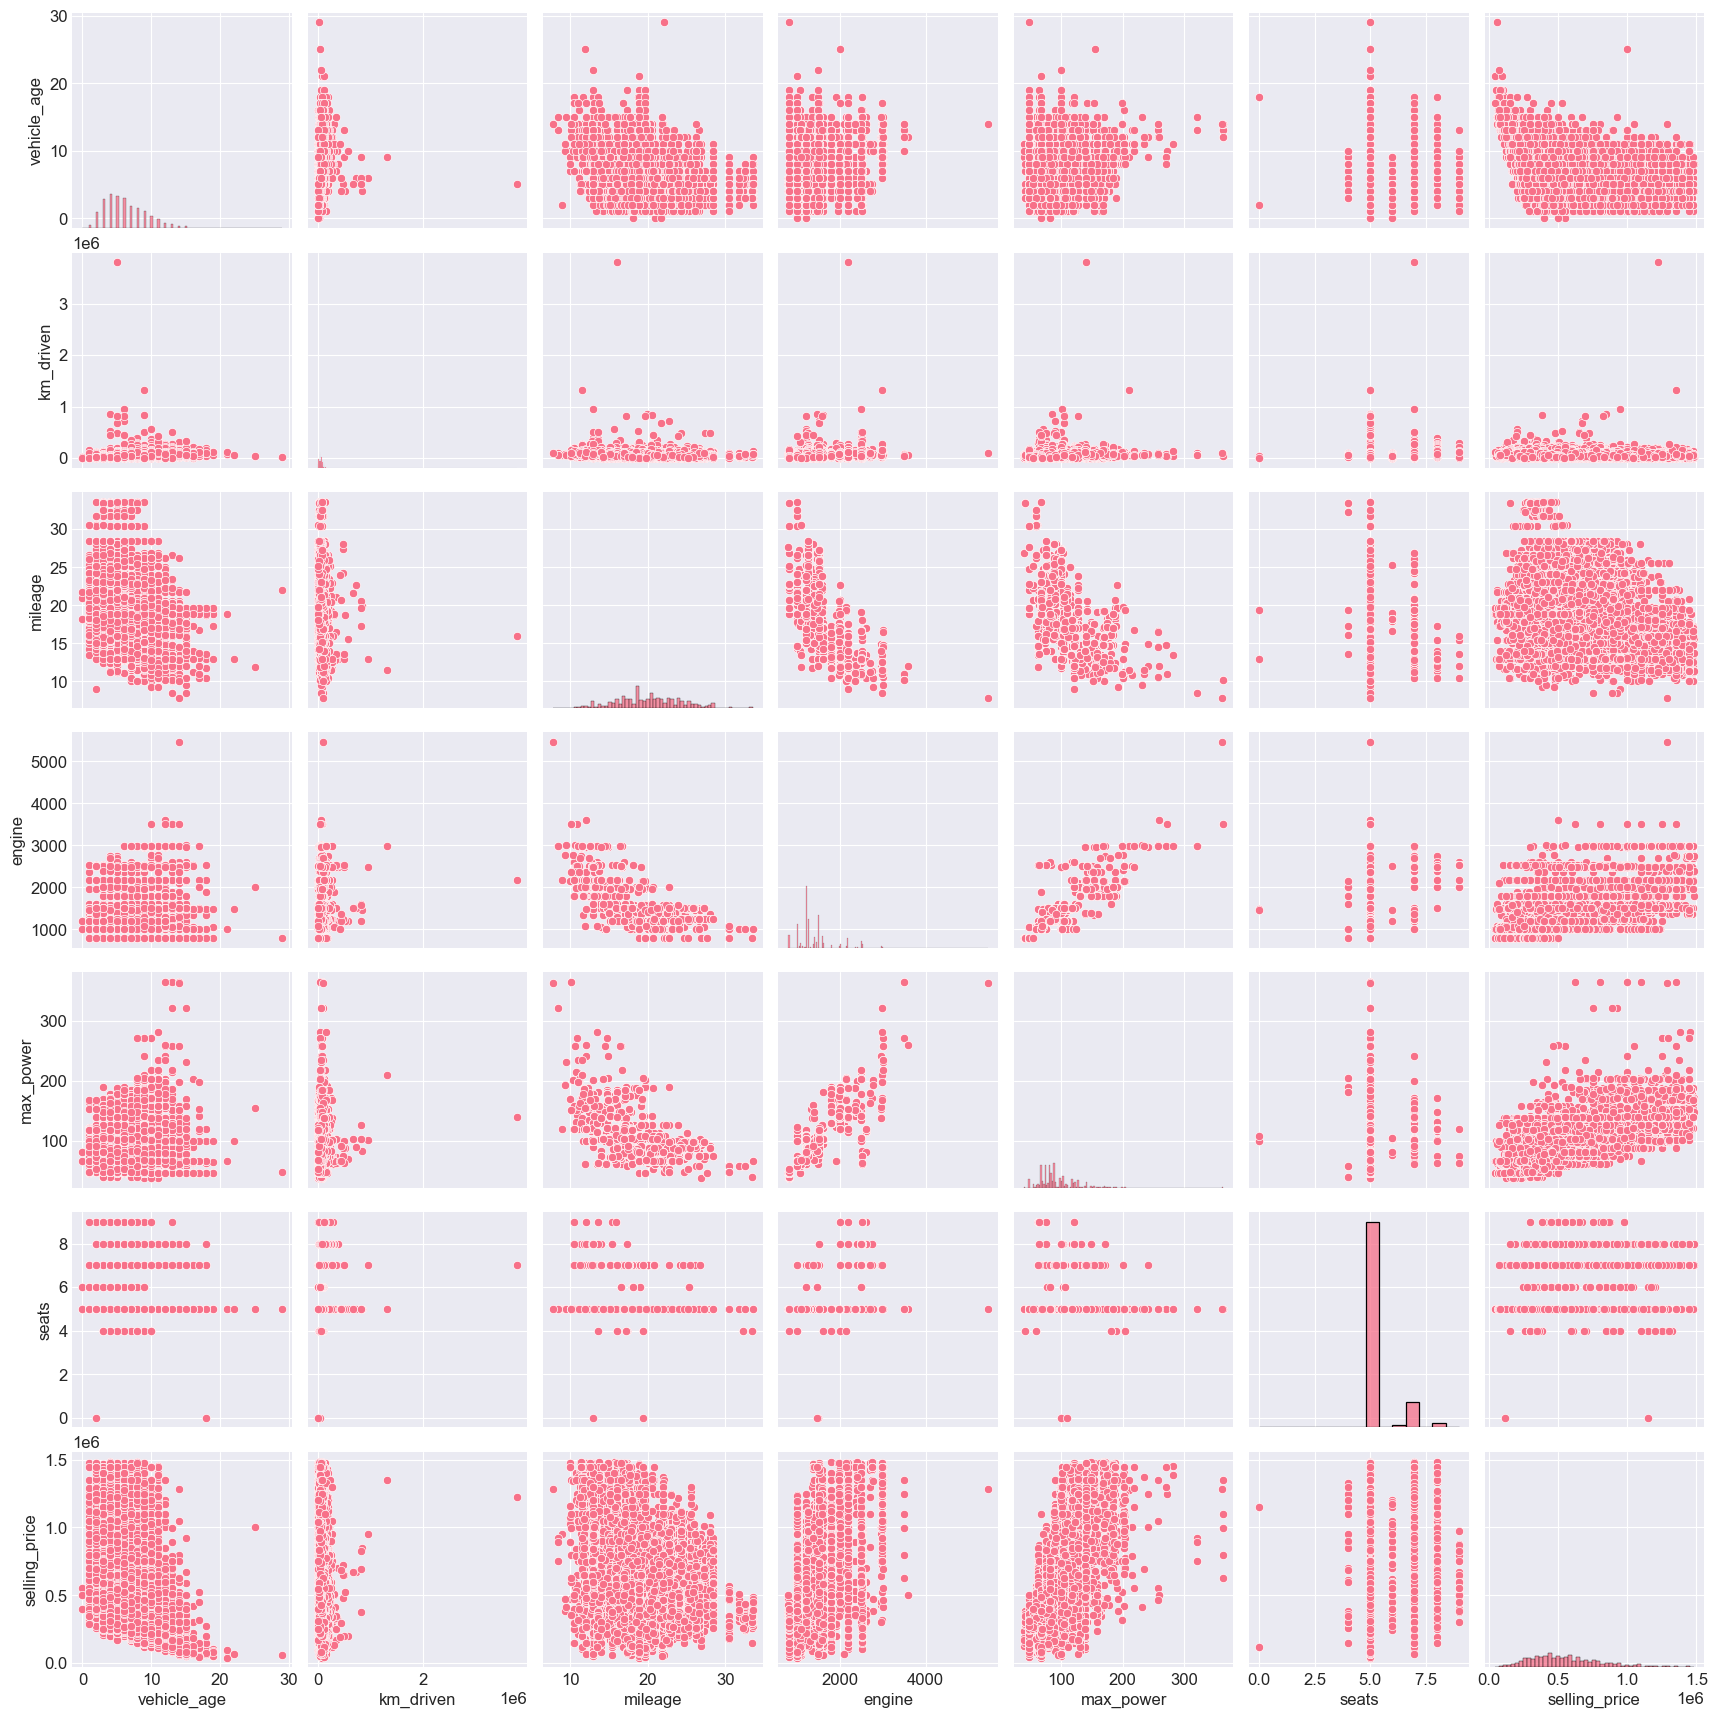

In [28]:
sns.pairplot(train[numeric_cols])
plt.show()

In [29]:
# Price per KM
train['price_per_km'] = train['selling_price'] / train['km_driven']

# Engine per seat
train['engine_per_seat'] = train['engine'] / train['seats']

In [30]:
print(train[numeric_cols].skew())

vehicle_age       0.810825
km_driven        28.551701
mileage           0.133200
engine            1.575937
max_power         1.851832
seats             2.342584
selling_price     0.839304
dtype: float64


In [31]:
train.to_csv("cleaned_data.csv", index=False)

In [32]:
insights = []

if train['vehicle_age'].corr(train['selling_price']) < 0:
    insights.append("Older cars have lower prices")

if train['engine'].corr(train['selling_price']) > 0:
    insights.append("Higher engine size increases price")

for i in insights:
    print("•", i)

• Older cars have lower prices
• Higher engine size increases price


In [33]:
train.to_csv("processed_for_model.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!
